In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/Customer-Churn-Prediction/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [4]:
df = pd.read_csv(path)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


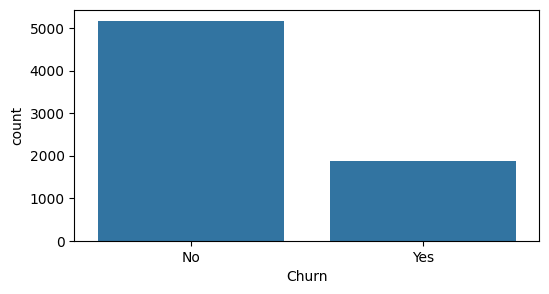

In [15]:
plt.figure(figsize=(6,3))
sns.countplot(x=df["Churn"])
plt.show()

In [18]:
df['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [21]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [22]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [23]:
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [26]:
df.dropna(inplace=True)

In [27]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


EDA

In [29]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


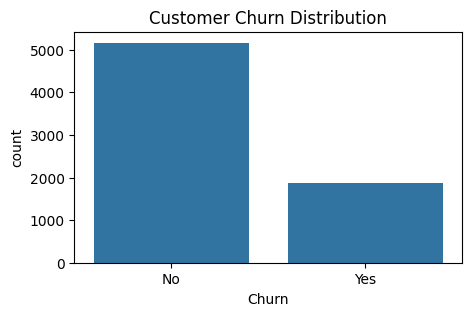

In [31]:
plt.figure(figsize=(5,3))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [32]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [33]:
categorical_cols = df.select_dtypes(include=["object"]).columns

categorical_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [34]:
df.drop("customerID", axis=1, inplace=True)

In [35]:
numerical_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

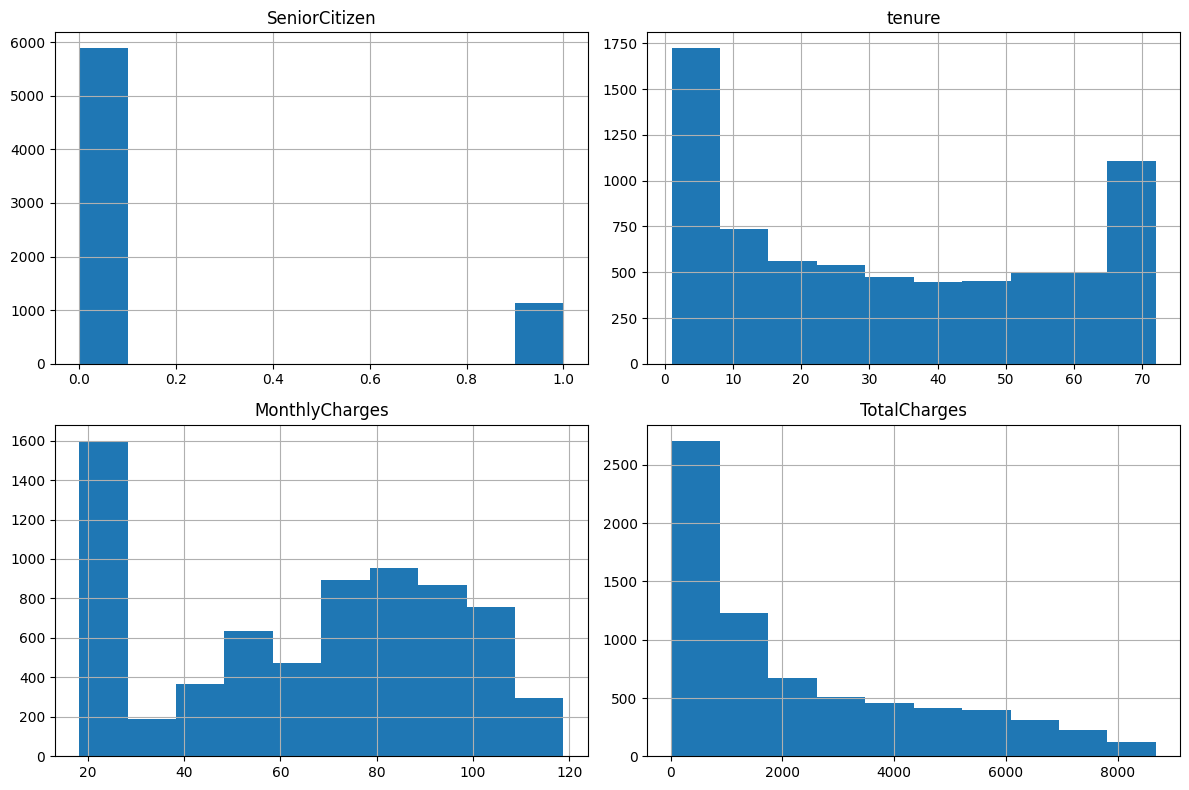

In [36]:
df[numerical_cols].hist(figsize=(12,8))

plt.tight_layout()
plt.show()

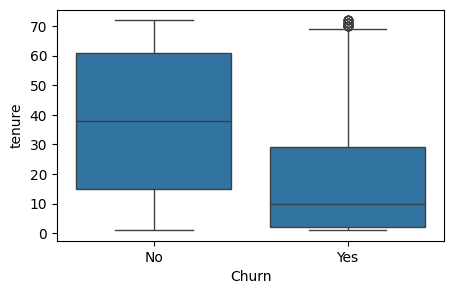

In [37]:
plt.figure(figsize=(5,3))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.show()

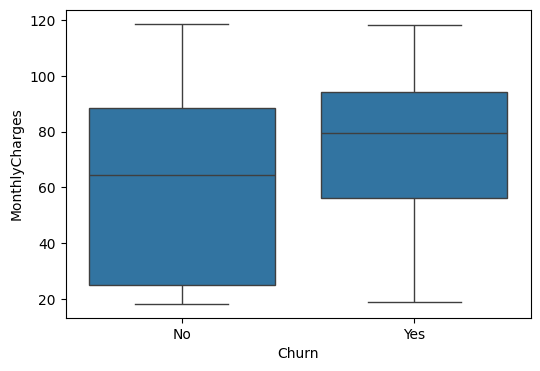

In [38]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.show()

In [39]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

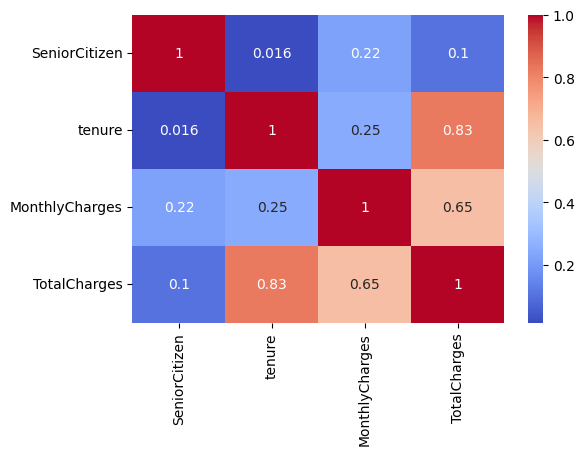

In [41]:
plt.figure(figsize=(6,4))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.show()

In [42]:
categorical_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

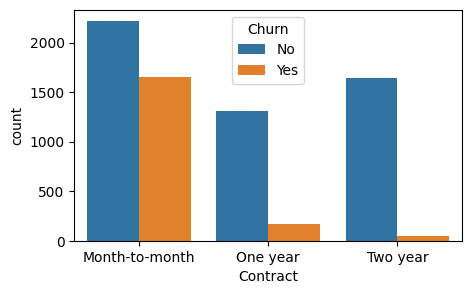

In [44]:
plt.figure(figsize=(5,3))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.show()

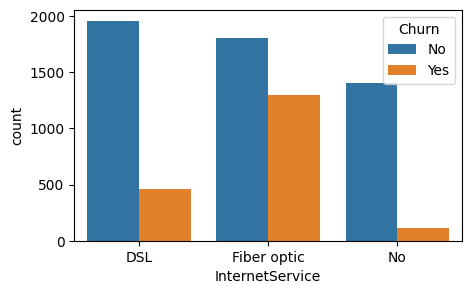

In [45]:
plt.figure(figsize=(5,3))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.show()

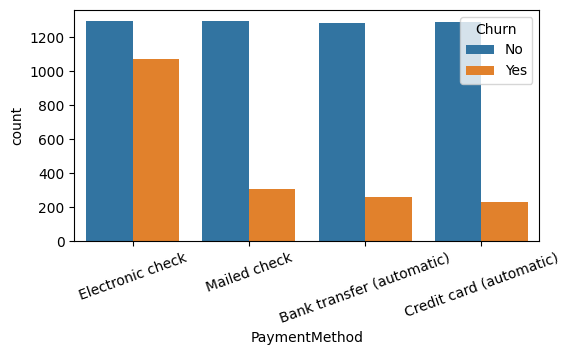

In [46]:
plt.figure(figsize=(6,3))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.show()

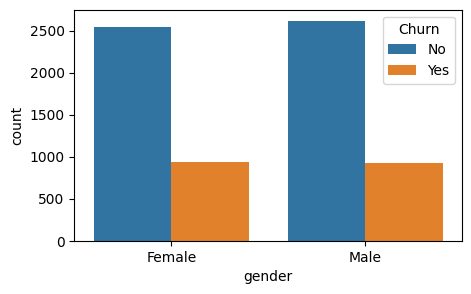

In [47]:
plt.figure(figsize=(5,3))

sns.countplot(x="gender", hue="Churn", data=df)

plt.show()

In [50]:
categorical_cols = df.select_dtypes(include=["object"]).columns

In [51]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("-"*50)

gender
['Female' 'Male']
--------------------------------------------------
Partner
['Yes' 'No']
--------------------------------------------------
Dependents
['No' 'Yes']
--------------------------------------------------
PhoneService
['No' 'Yes']
--------------------------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity
['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup
['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection
['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport
['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV
['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingM

In [53]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [54]:
binary_cols = []

for col in categorical_cols:
    if df[col].nunique() == 2:
        binary_cols.append(col)

binary_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

In [55]:
binary_cols.remove("Churn")

In [56]:
binary_cols

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [57]:
for col in binary_cols:
    df[col] = pd.factorize(df[col])[0]

In [58]:
df.sample()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3502,1,0,1,0,44,0,No phone service,DSL,Yes,No,Yes,No,Yes,Yes,One year,0,Electronic check,54.0,2440.25,0


In [59]:
multi_cols = []

for col in categorical_cols:
    if df[col].nunique() > 2:
        multi_cols.append(col)

multi_cols

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [60]:
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [61]:
df.sample()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3785,1,1,0,0,10,1,0,89.8,914.3,1,...,False,False,False,False,True,False,False,False,True,False


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   bool   
 11  MultipleL

In [65]:
bool_cols = df.select_dtypes(include=["bool"]).columns

for col in bool_cols:
    df[col] = df[col].astype(int)

In [66]:
df.sample()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2852,1,0,0,0,66,1,0,85.9,5595.3,0,...,1,0,1,0,1,0,1,0,0,0


In [67]:
df.to_csv(
    "/content/drive/MyDrive/Customer-Churn-Prediction/data/processed_churn.csv",
    index=False
)